In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/College/FLEX-Med/flex-med

/content/drive/MyDrive/College/FLEX-Med/flex-med


In [3]:
# Dependency Installation
!pip install fastapi uvicorn pyngrok nest-asyncio flwr["simulation"] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.3/323.3 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.1/250.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.1/727.1 kB 40.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 44.0.3 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.2 which

# **API Setup**

In [4]:
import os
import sys
import json
import logging
import subprocess
from typing import List, Tuple
import re
from datetime import datetime

from fastapi import FastAPI, BackgroundTasks, HTTPException
from pydantic import BaseModel
from starlette.middleware.cors import CORSMiddleware

# PyTorch and ML imports
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================

# Use environment variables with fallback
PROJECT_DIR = os.getenv("FLEX_MED_PROJECT_DIR", "/content/drive/MyDrive/College/FLEX-Med/flex-med")
LOG_FILE_PATH = os.path.join(PROJECT_DIR, "server_debug.log")
SIMULATION_LOG_PATH = os.path.join(PROJECT_DIR, "simulation_run.log")
DATA_JSON_PATH = os.getenv("FLEX_MED_DATA_JSON", os.path.join(PROJECT_DIR, "flex_med/data.json"))
PYPROJECT_PATH = os.path.join(PROJECT_DIR, "pyproject.toml")

# Evaluation configuration
DATA_ROOT = os.getenv("FLEX_MED_DATA_ROOT", "/content/drive/MyDrive/College/FLEX-Med/datasets")
PUBLIC_TEST_PATH = os.path.join(DATA_ROOT, "public_test")  # Public test dataset path

IMG_SIZE = 128
NUM_CLASSES = 2
CLASSES = ['Hem (Healthy)', 'ALL (Leukemia)']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(PROJECT_DIR, exist_ok=True)

# ==========================================
# 2. SERVER LOGGING SETUP
# ==========================================

logger = logging.getLogger("inference_logger")
logger.setLevel(logging.INFO)

if logger.hasHandlers():
    logger.handlers.clear()

file_handler = logging.FileHandler(LOG_FILE_PATH)
stream_handler = logging.StreamHandler(sys.stdout)

logger.addHandler(file_handler)
logger.addHandler(stream_handler)

logger.info("=== Flex-Med Orchestrator Started ===")

# ==========================================
# 3. EVALUATION HELPER FUNCTIONS
# ==========================================

def build_model(architecture):
    """Build model architecture"""
    if architecture == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    elif architecture == "mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    elif architecture == "densenet121":
        model = models.densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    return model

def load_model_weights(model, model_path, device):
    """Safely load model weights"""
    checkpoint = torch.load(model_path, map_location=device)

    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        model.load_state_dict(checkpoint['state_dict'])
    else:
        model.load_state_dict(checkpoint)

    return model

def get_test_loader(dataset_path, batch_size=32, split_data=False):
    """
    Load test dataset with optional splitting

    Args:
        dataset_path: Path to dataset
        batch_size: Batch size for loader
        split_data: If True, take 20% as test (for private data).
                   If False, use entire dataset (for public test data that's already separated)

    Returns:
        DataLoader for test dataset
    """
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
    ])

    dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

    if split_data:
        # Split: 80% train, 20% test (for private data)
        test_size = int(0.2 * len(dataset))
        train_size = len(dataset) - test_size
        generator = torch.Generator().manual_seed(42)
        _, test_dataset = torch.utils.data.random_split(
            dataset, [train_size, test_size], generator=generator
        )
    else:
        # Use entire dataset (for public test data that's already separated)
        test_dataset = dataset

    test_loader = DataLoader(test_dataset, batch_size=batch_size,
                            shuffle=False, num_workers=2)

    return test_loader

def calculate_essential_metrics(model, test_loader, device):
    """Calculate all essential metrics for a model"""
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics
    metrics = {
        'accuracy': float(accuracy_score(all_labels, all_preds)),
        'precision': float(precision_score(all_labels, all_preds, pos_label=1, zero_division=0)),
        'recall': float(recall_score(all_labels, all_preds, pos_label=1, zero_division=0)),
        'f1_score': float(f1_score(all_labels, all_preds, pos_label=1, zero_division=0)),
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        'roc_auc': float(roc_auc_score(all_labels, all_probs[:, 1])) if len(np.unique(all_labels)) > 1 else 0.0,
        'confusion_matrix': cm.tolist(),
        'num_test_samples': len(all_labels)
    }

    # Per-class accuracy
    for i, class_name in enumerate(CLASSES):
        class_mask = (all_labels == i)
        if class_mask.sum() > 0:
            class_acc = accuracy_score(all_labels[class_mask], all_preds[class_mask])
            key = 'healthy_accuracy' if i == 0 else 'leukemia_accuracy'
            metrics[key] = float(class_acc)
        else:
            key = 'healthy_accuracy' if i == 0 else 'leukemia_accuracy'
            metrics[key] = 0.0

    return metrics

def update_client_metrics(client_id, stage, metrics_dict):
    """
    Update client's metrics in data.json

    Args:
        client_id: Client ID (int)
        stage: Either 'pre_fl' or 'post_fl' (str)
        metrics_dict: Dictionary containing calculated metrics (dict)
    """
    with open(DATA_JSON_PATH, 'r') as f:
        clients = json.load(f)

    for client in clients:
        if client['id'] == client_id:
            # Handle both dict and string formats for backward compatibility
            # Use different variable name to avoid collision with metrics_dict parameter
            try:
                if isinstance(client['metrics'], str):
                    # Strip whitespace and quotes
                    metrics_str = client['metrics'].strip()

                    # Handle empty string
                    if metrics_str == '':
                        client_metrics = {}
                    # Handle double-encoded JSON like "\"{}\""
                    elif metrics_str.startswith('"') and metrics_str.endswith('"'):
                        # Remove outer quotes and try parsing again
                        metrics_str = metrics_str[1:-1]
                        if metrics_str == '{}' or metrics_str == '':
                            client_metrics = {}
                        else:
                            client_metrics = json.loads(metrics_str)
                    else:
                        client_metrics = json.loads(metrics_str)
                elif isinstance(client['metrics'], dict):
                    client_metrics = client['metrics']
                else:
                    client_metrics = {}
            except (json.JSONDecodeError, ValueError) as e:
                logger.warning(f"Invalid JSON in metrics for {client['client_name']}: {e}, resetting to empty dict")
                client_metrics = {}

            # Add new metrics under the stage
            client_metrics[stage] = {
                'accuracy': float(metrics_dict['accuracy']),
                'precision': float(metrics_dict['precision']),
                'recall': float(metrics_dict['recall']),
                'f1_score': float(metrics_dict['f1_score']),
                'specificity': float(metrics_dict['specificity']),
                'roc_auc': float(metrics_dict['roc_auc']),
                'healthy_accuracy': float(metrics_dict['healthy_accuracy']),
                'leukemia_accuracy': float(metrics_dict['leukemia_accuracy']),
                'confusion_matrix': metrics_dict['confusion_matrix'],
                'num_samples': int(metrics_dict['num_test_samples']),
                'evaluated_at': datetime.now().isoformat()
            }

            # Calculate improvement if both stages exist
            if 'pre_fl' in client_metrics and 'post_fl' in client_metrics:
                client_metrics['improvement'] = {
                    'accuracy': client_metrics['post_fl']['accuracy'] - client_metrics['pre_fl']['accuracy'],
                    'precision': client_metrics['post_fl']['precision'] - client_metrics['pre_fl']['precision'],
                    'recall': client_metrics['post_fl']['recall'] - client_metrics['pre_fl']['recall'],
                    'f1_score': client_metrics['post_fl']['f1_score'] - client_metrics['pre_fl']['f1_score'],
                    'roc_auc': client_metrics['post_fl']['roc_auc'] - client_metrics['pre_fl']['roc_auc'],
                    'specificity': client_metrics['post_fl']['specificity'] - client_metrics['pre_fl']['specificity'],
                    'healthy_accuracy': client_metrics['post_fl']['healthy_accuracy'] - client_metrics['pre_fl']['healthy_accuracy'],
                    'leukemia_accuracy': client_metrics['post_fl']['leukemia_accuracy'] - client_metrics['pre_fl']['leukemia_accuracy'],
                }

            # Save as dict (no need for nested JSON strings)
            client['metrics'] = client_metrics

            logger.info(f"✅ Updated {stage} metrics for {client['client_name']}")
            logger.info(f"   Accuracy: {metrics_dict['accuracy']:.2%}")

            break

    # Write back to file
    with open(DATA_JSON_PATH, 'w') as f:
        json.dump(clients, f, indent=2)


def evaluate_all_clients_pre_fl():
    """Evaluate all clients BEFORE federated learning on PUBLIC TEST SET"""
    logger.info("\n" + "="*70)
    logger.info("PRE-FL EVALUATION - Baseline Metrics (Public Test Set)")
    logger.info("="*70)

    # Verify public test path exists
    if not os.path.exists(PUBLIC_TEST_PATH):
        logger.error(f"❌ Public test path not found: {PUBLIC_TEST_PATH}")
        raise FileNotFoundError(f"Public test data not found at {PUBLIC_TEST_PATH}")

    logger.info(f"📊 Evaluating all clients on: {PUBLIC_TEST_PATH}")

    with open(DATA_JSON_PATH, 'r') as f:
        clients = json.load(f)

    for client in clients:
        client_id = client['id']
        client_name = client['client_name']
        model_type = client['model_type']
        model_path = client['model_path']

        logger.info(f"\n{'─'*70}")
        logger.info(f"Client {client_id}: {client_name} ({model_type})")
        logger.info(f"{'─'*70}")

        try:
            # Build model
            model = build_model(model_type)

            # Load initial weights (untrained or pre-trained)
            if os.path.exists(model_path):
                model = load_model_weights(model, model_path, DEVICE)
                logger.info(f"✓ Loaded model from: {model_path}")
            else:
                logger.info(f"⚠️  Using freshly initialized model (no saved weights)")

            # Load PUBLIC test data (no splitting - already separated)
            test_loader = get_test_loader(PUBLIC_TEST_PATH, split_data=False)
            logger.info(f"✓ Loaded {len(test_loader.dataset)} test samples from public test set")

            # Calculate metrics
            metrics = calculate_essential_metrics(model, test_loader, DEVICE)

            # Save to data.json
            update_client_metrics(client_id, 'pre_fl', metrics)

            # Print summary
            logger.info(f"\n📈 Pre-FL Metrics:")
            logger.info(f"   Accuracy:  {metrics['accuracy']:.2%}")
            logger.info(f"   Precision: {metrics['precision']:.3f}")
            logger.info(f"   Recall:    {metrics['recall']:.3f}")
            logger.info(f"   F1-Score:  {metrics['f1_score']:.3f}")
            logger.info(f"   ROC-AUC:   {metrics['roc_auc']:.3f}")

        except Exception as e:
            logger.error(f"❌ Pre-FL evaluation failed for {client_name}: {e}")
            import traceback
            logger.error(traceback.format_exc())

    logger.info("\n" + "="*70)
    logger.info("✅ Pre-FL evaluation complete! Metrics saved to data.json")
    logger.info("="*70)


def evaluate_all_clients_post_fl():
    """Evaluate all clients AFTER federated learning on PUBLIC TEST SET"""
    logger.info("\n" + "="*70)
    logger.info("POST-FL EVALUATION - Final Metrics (Public Test Set)")
    logger.info("="*70)

    # Verify public test path exists
    if not os.path.exists(PUBLIC_TEST_PATH):
        logger.error(f"❌ Public test path not found: {PUBLIC_TEST_PATH}")
        raise FileNotFoundError(f"Public test data not found at {PUBLIC_TEST_PATH}")

    logger.info(f"📊 Evaluating all clients on: {PUBLIC_TEST_PATH}")

    with open(DATA_JSON_PATH, 'r') as f:
        clients = json.load(f)

    for client in clients:
        client_id = client['id']
        client_name = client['client_name']
        model_type = client['model_type']
        model_path = client['model_path']

        logger.info(f"\n{'─'*70}")
        logger.info(f"Client {client_id}: {client_name} ({model_type})")
        logger.info(f"{'─'*70}")

        try:
            # Build model
            model = build_model(model_type)

            # Load trained weights (after FL)
            if os.path.exists(model_path):
                model = load_model_weights(model, model_path, DEVICE)
                logger.info(f"✓ Loaded trained model from: {model_path}")
            else:
                logger.error(f"❌ Error: Trained model not found at {model_path}")
                continue

            # Load PUBLIC test data (no splitting - already separated)
            test_loader = get_test_loader(PUBLIC_TEST_PATH, split_data=False)
            logger.info(f"✓ Loaded {len(test_loader.dataset)} test samples from public test set")

            # Calculate metrics
            metrics = calculate_essential_metrics(model, test_loader, DEVICE)

            # Save to data.json
            update_client_metrics(client_id, 'post_fl', metrics)

            # Print summary
            logger.info(f"\n📈 Post-FL Metrics:")
            logger.info(f"   Accuracy:  {metrics['accuracy']:.2%}")
            logger.info(f"   Precision: {metrics['precision']:.3f}")
            logger.info(f"   Recall:    {metrics['recall']:.3f}")
            logger.info(f"   F1-Score:  {metrics['f1_score']:.3f}")
            logger.info(f"   ROC-AUC:   {metrics['roc_auc']:.3f}")

            # Show improvement if pre_fl exists
            client_metrics = client['metrics'] if isinstance(client['metrics'], dict) else json.loads(client['metrics'])

            if 'pre_fl' in client_metrics and 'improvement' in client_metrics:
                imp = client_metrics['improvement']
                logger.info(f"\n🚀 Improvement:")
                logger.info(f"   Accuracy:  {imp['accuracy']:+.2%}")
                logger.info(f"   F1-Score:  {imp['f1_score']:+.3f}")
                logger.info(f"   ROC-AUC:   {imp['roc_auc']:+.3f}")

        except Exception as e:
            logger.error(f"❌ Post-FL evaluation failed for {client_name}: {e}")
            import traceback
            logger.error(traceback.format_exc())

    logger.info("\n" + "="*70)
    logger.info("✅ Post-FL evaluation complete! Metrics saved to data.json")
    logger.info("="*70)

def generate_comparison_report():
    """Generate comprehensive comparison report"""
    with open(DATA_JSON_PATH, 'r') as f:
        clients = json.load(f)

    logger.info("\n" + "="*70)
    logger.info("FEDERATED LEARNING EVALUATION REPORT")
    logger.info("="*70)

    logger.info(f"\n{'Client':<20} {'Pre-FL':<12} {'Post-FL':<12} {'Δ Accuracy':<15} {'Δ F1':<10}")
    logger.info("─"*75)

    for client in clients:
        name = client['client_name']
        metrics = client['metrics'] if isinstance(client['metrics'], dict) else json.loads(client['metrics'])

        if 'pre_fl' in metrics and 'post_fl' in metrics:
            pre_acc = metrics['pre_fl']['accuracy']
            post_acc = metrics['post_fl']['accuracy']
            imp_acc = metrics['improvement']['accuracy']
            imp_f1 = metrics['improvement']['f1_score']

            # Color coding
            acc_str = f"{imp_acc:+.2%}"
            if imp_acc > 0:
                acc_str = "🟢 " + acc_str
            elif imp_acc < 0:
                acc_str = "🔴 " + acc_str
            else:
                acc_str = "⚪ " + acc_str

            logger.info(f"{name:<20} {pre_acc:<11.2%} {post_acc:<11.2%} {acc_str:<15} {imp_f1:+.3f}")
        else:
            logger.info(f"{name:<20} {'N/A':<12} {'N/A':<12} {'N/A':<15} {'N/A'}")

    logger.info("="*70)

    # Summary statistics
    improvements = []
    for client in clients:
        metrics = client['metrics'] if isinstance(client['metrics'], dict) else json.loads(client['metrics'])
        if 'improvement' in metrics:
            improvements.append(metrics['improvement']['accuracy'])

    if improvements:
        avg_improvement = np.mean(improvements)
        logger.info(f"\n📊 Summary:")
        logger.info(f"   Average Improvement: {avg_improvement:+.2%}")
        logger.info(f"   Best Improvement:    {max(improvements):+.2%}")
        logger.info(f"   Worst Improvement:   {min(improvements):+.2%}")
        logger.info(f"   Clients Improved:    {sum(1 for x in improvements if x > 0)}/{len(improvements)}")

# ==========================================
# 4. CONFIGURATION VALIDATION
# ==========================================

def validate_client_config(client) -> Tuple[bool, str]:
    """
    Validate client configuration

    Returns:
        (is_valid, error_message)
    """
    # Validate model type
    valid_models = ['resnet18', 'mobilenet_v2', 'densenet121']
    if client.model_type not in valid_models:
        return False, f"Invalid model type: {client.model_type}. Must be one of {valid_models}"

    # Validate dataset path if has_local_data
    if client.has_local_data:
        if not client.dataset_path:
            return False, f"Client {client.client_name} has_local_data=True but no dataset_path"
        if not os.path.exists(client.dataset_path):
            return False, f"Dataset path does not exist: {client.dataset_path}"

    # Validate model path
    if not client.model_path:
        return False, f"Client {client.client_name} has no model_path"

    model_dir = os.path.dirname(client.model_path)
    if not os.path.exists(model_dir):
        try:
            os.makedirs(model_dir, exist_ok=True)
            logger.info(f"Created model directory: {model_dir}")
        except Exception as e:
            return False, f"Cannot create model directory: {model_dir}, error: {e}"

    return True, ""

# ==========================================
# 5. CREATE RUN SCRIPT
# ==========================================

def create_run_script():
    """Creates the shell script that runs the Flower simulation."""
    script_content = f"""#!/bin/bash
cd "{PROJECT_DIR}"

echo "[Script] Starting Flex-Med Simulation at $(date)..."

# Only install the local package in editable mode (Fast & Lightweight)
pip install -e . -q

# Run Flower CLI directly
flwr run .
"""
    script_path = os.path.join(PROJECT_DIR, "run_simulation.sh")

    with open(script_path, "w") as f:
        f.write(script_content)

    os.chmod(script_path, 0o755)
    logger.info(f"Created run_simulation.sh at {script_path}")

    return script_path

SCRIPT_PATH = create_run_script()

# ==========================================
# 6. BACKGROUND TASK (WITH POST-FL EVALUATION)
# ==========================================

def run_simulation_task():
    """
    Runs the FL simulation and evaluates Post-FL performance
    """
    logger.info("="*70)
    logger.info("Starting Flower Simulation in Background")
    logger.info("="*70)

    try:
        # ===== STEP 1: RUN FL SIMULATION =====
        logger.info("\n[Background Task] Step 1: Running Flower Simulation...")

        with open(SIMULATION_LOG_PATH, "w") as log_file:
            process = subprocess.run(
                ["bash", SCRIPT_PATH],
                stdout=log_file,
                stderr=log_file,
                text=True
            )

        return_code = process.returncode

        # ===== STEP 2: CHECK IF FL SUCCEEDED =====
        if return_code == 0:
            logger.info("\n" + "="*70)
            logger.info("✅ Federated Learning Simulation COMPLETED Successfully")
            logger.info("="*70)

            # ===== STEP 3: EVALUATE POST-FL PERFORMANCE =====
            logger.info("\n[Background Task] Step 2: Evaluating Post-FL Performance...")

            post_fl_success = False
            post_fl_metrics = {}
            improvement_summary = {}

            try:
                # Evaluate all clients after FL
                evaluate_all_clients_post_fl()

                logger.info("✅ Post-FL metrics captured and saved to data.json")
                post_fl_success = True

                # Load the metrics to log results
                with open(DATA_JSON_PATH, 'r') as f:
                    clients_data = json.load(f)

                logger.info("\n📊 Post-FL Performance:")
                logger.info("-" * 70)

                for client in clients_data:
                    metrics = client['metrics'] if isinstance(client['metrics'], dict) else json.loads(client['metrics'])

                    if 'post_fl' in metrics:
                        post_fl_metrics[client['client_name']] = {
                            'accuracy': metrics['post_fl']['accuracy'],
                            'f1_score': metrics['post_fl']['f1_score'],
                            'roc_auc': metrics['post_fl']['roc_auc']
                        }

                        logger.info(f"  {client['client_name']:20}: {metrics['post_fl']['accuracy']:.2%}")

                    # Log improvement if available
                    if 'improvement' in metrics:
                        improvement = metrics['improvement']
                        improvement_summary[client['client_name']] = improvement['accuracy']

                        improvement_str = f"{improvement['accuracy']:+.2%}"
                        if improvement['accuracy'] > 0:
                            improvement_str = "🟢 " + improvement_str
                        elif improvement['accuracy'] < 0:
                            improvement_str = "🔴 " + improvement_str
                        else:
                            improvement_str = "⚪ " + improvement_str

                        logger.info(f"    Improvement: {improvement_str}")

                logger.info("-" * 70)

                # Calculate overall statistics
                if improvement_summary:
                    avg_improvement = sum(improvement_summary.values()) / len(improvement_summary)
                    logger.info(f"\n📈 Overall Statistics:")
                    logger.info(f"  Average Improvement: {avg_improvement:+.2%}")
                    logger.info(f"  Best Improvement: {max(improvement_summary.values()):+.2%} "
                              f"({max(improvement_summary, key=improvement_summary.get)})")
                    logger.info(f"  Clients Improved: {sum(1 for x in improvement_summary.values() if x > 0)}"
                              f"/{len(improvement_summary)}")

            except Exception as e:
                logger.error(f"\n⚠️ Post-FL evaluation failed: {e}")
                logger.error("Simulation completed but metrics not captured")
                import traceback
                logger.error(traceback.format_exc())

            # ===== STEP 4: GENERATE COMPARISON REPORT =====
            if post_fl_success:
                logger.info("\n[Background Task] Step 3: Generating Comparison Report...")

                try:
                    generate_comparison_report()
                    logger.info("✅ Comparison report generated")
                except Exception as e:
                    logger.error(f"⚠️ Report generation failed: {e}")

            # ===== STEP 5: SAVE COMPLETION STATUS =====
            logger.info("\n[Background Task] Step 4: Saving completion status...")

            try:
                completion_status = {
                    "status": "completed",
                    "timestamp": datetime.now().isoformat(),
                    "return_code": return_code,
                    "post_fl_evaluation": {
                        "success": post_fl_success,
                        "metrics": post_fl_metrics,
                        "improvements": improvement_summary
                    },
                    "log_path": SIMULATION_LOG_PATH
                }

                status_path = os.path.join(PROJECT_DIR, "simulation_status.json")
                with open(status_path, 'w') as f:
                    json.dump(completion_status, f, indent=2)

                logger.info(f"✅ Status saved to: {status_path}")

            except Exception as e:
                logger.error(f"⚠️ Failed to save status: {e}")

            logger.info("\n" + "="*70)
            logger.info("🎉 COMPLETE WORKFLOW FINISHED SUCCESSFULLY")
            logger.info("="*70)

        else:
            # FL simulation failed
            logger.error("\n" + "="*70)
            logger.error(f"❌ Federated Learning Simulation FAILED")
            logger.error(f"   Return Code: {return_code}")
            logger.error("="*70)

            # Save error status
            try:
                error_status = {
                    "status": "failed",
                    "timestamp": datetime.now().isoformat(),
                    "return_code": return_code,
                    "error": "Simulation failed",
                    "log_path": SIMULATION_LOG_PATH
                }

                status_path = os.path.join(PROJECT_DIR, "simulation_status.json")
                with open(status_path, 'w') as f:
                    json.dump(error_status, f, indent=2)

            except Exception as e:
                logger.error(f"Failed to save error status: {e}")

    except Exception as e:
        logger.error(f"\n❌ Simulation error: {e}")
        import traceback
        logger.error(traceback.format_exc())

# ==========================================
# 7. PYDANTIC MODELS
# ==========================================

class ClientConfig(BaseModel):
    id: int
    created_at: str
    client_name: str
    model_type: str
    dataset_path: str | None
    status: str
    has_local_data: bool
    model_path: str
    metrics: str

# ==========================================
# 8. FASTAPI APP
# ==========================================

app = FastAPI(title="Flex-Med Orchestrator")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ==========================================
# 9. ENDPOINTS
# ==========================================

@app.get("/")
def read_root():
    return {"message": "Flex-Med Orchestrator is running"}

def update_data_json(clients: List[ClientConfig], path: str = DATA_JSON_PATH):
    """Save client configuration to data.json"""
    try:
        client_dicts = [c.dict() for c in clients]
        os.makedirs(os.path.dirname(path), exist_ok=True)

        with open(path, "w") as f:
            json.dump(client_dicts, f, indent=2)

        logger.info(f"✓ Updated data.json with {len(clients)} clients")
        return True
    except Exception as e:
        logger.error(f"Failed to update data.json: {e}")
        return False

def update_pyproject_toml(num_clients: int, path: str = PYPROJECT_PATH):
    """Update pyproject.toml with correct num-supernodes"""
    try:
        if not os.path.exists(path):
            logger.error(f"pyproject.toml not found at {path}")
            return False

        with open(path, 'r') as f:
            content = f.read()

        pattern = r'(options\.num-supernodes\s*=\s*)\d+'

        if not re.search(pattern, content):
            logger.warning("num-supernodes not found in pyproject.toml")
            return False

        old_match = re.search(r'options\.num-supernodes\s*=\s*(\d+)', content)
        old_value = old_match.group(1) if old_match else "unknown"

        new_content = re.sub(pattern, f'\\g<1>{num_clients}', content)

        with open(path, 'w') as f:
            f.write(new_content)

        logger.info(f"✓ Updated pyproject.toml: num-supernodes {old_value} → {num_clients}")
        return True

    except Exception as e:
        logger.error(f"Failed to update pyproject.toml: {e}")
        return False

@app.post("/start_fl")
async def start_fl(
    clients: List[ClientConfig],
    background_tasks: BackgroundTasks,
):
    """
    Start federated learning simulation with dynamic client configuration.

    This endpoint:
    1. Validates client configurations
    2. Saves client config to data.json
    3. Updates pyproject.toml with correct num-supernodes
    4. Evaluates Pre-FL baseline metrics on PUBLIC TEST SET
    5. Triggers the FL simulation in background
    """

    num_clients = len(clients)
    logger.info(f"=" * 70)
    logger.info(f"Received FL start request for {num_clients} clients")
    logger.info(f"=" * 70)

    # Log client details
    for i, client in enumerate(clients):
        data_status = "Has Data" if client.has_local_data else "Free Rider"
        logger.info(f"  Client {i}: {client.client_name:20} | {client.model_type:15} | {data_status}")

    # ===== VALIDATION: CHECK CLIENT CONFIGS =====
    logger.info("\n[Endpoint] Validating client configurations...")

    validation_errors = []
    for i, client in enumerate(clients):
        is_valid, error_msg = validate_client_config(client)
        if not is_valid:
            validation_errors.append(f"Client {i}: {error_msg}")

    if validation_errors:
        error_detail = "\n".join(validation_errors)
        logger.error(f"Configuration validation failed:\n{error_detail}")
        raise HTTPException(
            status_code=400,
            detail=f"Invalid client configuration:\n{error_detail}"
        )

    logger.info("✓ All client configurations validated")

    # ===== STEP 1: UPDATE DATA.JSON =====
    logger.info("\n[Endpoint] Step 1: Updating data.json...")

    if not update_data_json(clients, DATA_JSON_PATH):
        raise HTTPException(
            status_code=500,
            detail="Failed to save client configuration to data.json"
        )

    # ===== STEP 2: UPDATE PYPROJECT.TOML =====
    logger.info("\n[Endpoint] Step 2: Updating pyproject.toml...")

    if not update_pyproject_toml(num_clients, PYPROJECT_PATH):
        logger.warning("Failed to update pyproject.toml, but continuing...")

    # ===== STEP 3: EVALUATE PRE-FL BASELINES ON PUBLIC TEST SET =====
    logger.info("\n[Endpoint] Step 3: Evaluating Pre-FL baselines on public test set...")

    pre_fl_success = False
    pre_fl_metrics = {}

    try:
        # Evaluate all clients before FL starts (on public test set)
        evaluate_all_clients_pre_fl()

        logger.info("✅ Pre-FL baseline metrics captured and saved to data.json")
        pre_fl_success = True

        # Load the metrics to return in response
        with open(DATA_JSON_PATH, 'r') as f:
            clients_data = json.load(f)

        for client in clients_data:
            metrics = client['metrics'] if isinstance(client['metrics'], dict) else json.loads(client['metrics'])
            if 'pre_fl' in metrics:
                pre_fl_metrics[client['client_name']] = {
                    'accuracy': metrics['pre_fl']['accuracy'],
                    'f1_score': metrics['pre_fl']['f1_score'],
                    'roc_auc': metrics['pre_fl']['roc_auc']
                }

        logger.info(f"  Baseline Accuracies (Public Test Set):")
        for name, m in pre_fl_metrics.items():
            logger.info(f"    {name}: {m['accuracy']:.2%}")

    except Exception as e:
        logger.error(f"⚠️ Pre-FL evaluation failed: {e}")
        logger.error(f"   Continuing with FL simulation anyway...")
        import traceback
        logger.error(traceback.format_exc())

    # ===== STEP 4: TRIGGER SIMULATION =====
    logger.info("\n[Endpoint] Step 4: Starting FL simulation...")
    logger.info(f"  - Number of clients: {num_clients}")
    logger.info(f"  - Active participants: {sum(1 for c in clients if c.has_local_data)}")
    logger.info(f"  - Free riders: {sum(1 for c in clients if not c.has_local_data)}")
    logger.info(f"=" * 70 + "\n")

    # Trigger the background task
    background_tasks.add_task(run_simulation_task)

    return {
        "status": "accepted",
        "message": f"Federated simulation started with {num_clients} clients",
        "num_clients": num_clients,
        "active_participants": sum(1 for c in clients if c.has_local_data),
        "free_riders": sum(1 for c in clients if not c.has_local_data),
        "pre_fl_evaluation": {
            "success": pre_fl_success,
            "metrics": pre_fl_metrics
        },
        "config_updated": {
            "data_json": DATA_JSON_PATH,
            "pyproject_toml": PYPROJECT_PATH
        },
        "log_path": SIMULATION_LOG_PATH
    }

@app.get("/simulation/status")
async def get_simulation_status():
    """Get the current status of the FL simulation"""
    status_path = os.path.join(PROJECT_DIR, "simulation_status.json")

    if os.path.exists(status_path):
        with open(status_path, 'r') as f:
            status = json.load(f)
        return status
    else:
        return {
            "status": "not_started",
            "message": "No simulation has been run yet"
        }

@app.get("/metrics/comparison")
async def get_metrics_comparison():
    """Get detailed comparison of pre-FL vs post-FL metrics"""
    try:
        with open(DATA_JSON_PATH, 'r') as f:
            clients = json.load(f)

        comparison = []

        for client in clients:
            metrics = client['metrics'] if isinstance(client['metrics'], dict) else json.loads(client['metrics'])

            client_data = {
                'id': client['id'],
                'name': client['client_name'],
                'model_type': client['model_type'],
                'has_data': client['has_local_data']
            }

            if 'pre_fl' in metrics:
                client_data['pre_fl'] = {
                    'accuracy': metrics['pre_fl']['accuracy'],
                    'precision': metrics['pre_fl']['precision'],
                    'recall': metrics['pre_fl']['recall'],
                    'f1_score': metrics['pre_fl']['f1_score'],
                    'roc_auc': metrics['pre_fl']['roc_auc'],
                    'healthy_accuracy': metrics['pre_fl']['healthy_accuracy'],
                    'leukemia_accuracy': metrics['pre_fl']['leukemia_accuracy']
                }

            if 'post_fl' in metrics:
                client_data['post_fl'] = {
                    'accuracy': metrics['post_fl']['accuracy'],
                    'precision': metrics['post_fl']['precision'],
                    'recall': metrics['post_fl']['recall'],
                    'f1_score': metrics['post_fl']['f1_score'],
                    'roc_auc': metrics['post_fl']['roc_auc'],
                    'healthy_accuracy': metrics['post_fl']['healthy_accuracy'],
                    'leukemia_accuracy': metrics['post_fl']['leukemia_accuracy']
                }

            if 'improvement' in metrics:
                client_data['improvement'] = metrics['improvement']

            comparison.append(client_data)

        # Calculate summary statistics
        if any('improvement' in c for c in comparison):
            improvements = [c['improvement']['accuracy'] for c in comparison if 'improvement' in c]
            summary = {
                'total_clients': len(comparison),
                'evaluated_clients': len(improvements),
                'avg_improvement': sum(improvements) / len(improvements) if improvements else 0,
                'best_improvement': max(improvements) if improvements else 0,
                'worst_improvement': min(improvements) if improvements else 0,
                'all_improved': all(x > 0 for x in improvements)
            }
        else:
            summary = {
                'total_clients': len(comparison),
                'evaluated_clients': 0,
                'message': 'No FL evaluation completed yet'
            }

        return {
            'clients': comparison,
            'summary': summary
        }

    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Failed to load metrics: {str(e)}")

print("✅ Flex-Med Orchestrator Ready")

=== Flex-Med Orchestrator Started ===


INFO:inference_logger:=== Flex-Med Orchestrator Started ===


Created run_simulation.sh at /content/drive/MyDrive/College/FLEX-Med/flex-med/run_simulation.sh


INFO:inference_logger:Created run_simulation.sh at /content/drive/MyDrive/College/FLEX-Med/flex-med/run_simulation.sh


✅ Flex-Med Orchestrator Ready


# **NGROK Setup**

In [5]:
import nest_asyncio
import uvicorn
import subprocess
import threading
from pyngrok import ngrok
from pyngrok.process import kill_process
from fastapi import FastAPI, BackgroundTasks, HTTPException
from starlette.middleware.cors import CORSMiddleware

# 0. Cleanup
try:
    ngrok.disconnect()
    kill_process()
except:
    pass

# 1. Auth & Tunnel
# REPLACE WITH YOUR ACTUAL TOKEN
AUTH_TOKEN = "2nI3IUybQHGO30McAH7x4UJRiND_695D6z3DbKjWLrq7N1ATy"
ngrok.set_auth_token(AUTH_TOKEN)

http_tunnel = ngrok.connect(8000)
public_url = http_tunnel.public_url

print(f"🌐 API URL: {public_url}")
print(f"🚀 POST to start FL: {public_url}/start_fl")

# 2. Run Uvicorn
nest_asyncio.apply()

def run_uvicorn():
    uvicorn.run(app, port=8000, host="0.0.0.0")

thread = threading.Thread(target=run_uvicorn)
thread.start()

🌐 API URL: https://82cb07f51487.ngrok-free.app
🚀 POST to start FL: https://82cb07f51487.ngrok-free.app/start_fl


In [ ]:
!tail -f "/content/drive/MyDrive/College/FLEX-Med/flex-med/simulation_run.log"

[Script] Starting Flex-Med Simulation at Sat Jan  3 12:07:04 PM UTC 2026...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.0/87.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.7 MB/s eta 0:00:00


In [ ]:
# Kill any process running on port 8000
!fuser -k 8000/tcp

print("Attempted to kill processes on port 8000. Please re-run the FastAPI server cell now.")

# **Model Inference Testing**


FLEX-Med Model Testing Suite
Testing Image: allidb_Im004_1.tif

Testing: ResNet-18 (Asiri)
Architecture: resnet18
Model Path: /content/drive/MyDrive/College/models/Asiri.pt
Building resnet18 architecture...
Loading weights from Asiri.pt...
   ✓ Loaded from checkpoint (round 5)
✅ Model loaded successfully
Processing image: allidb_Im004_1.tif...

📊 Results:
   True Label:  ALL (Leukemia)
   Predicted:   Hem (Healthy)
   Confidence:  99.26%
   Logits:      [ 2.5819163 -2.3168664]
   Probs:       Healthy=99.26%, Leukemia=0.74%
   Status:      ❌ INCORRECT


/tmp/ipython-input-4077186155.py:292: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


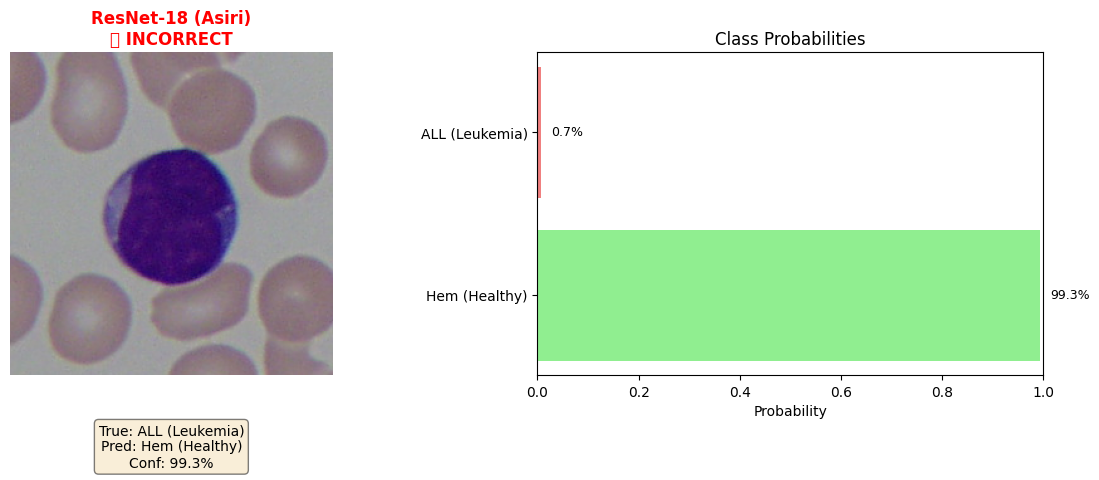


Testing: MobileNetV2 (Delmon)
Architecture: mobilenet_v2
Model Path: /content/drive/MyDrive/College/models/Delmon.pt
Building mobilenet_v2 architecture...
Loading weights from Delmon.pt...
   ✓ Loaded from checkpoint (round 5)
✅ Model loaded successfully
Processing image: allidb_Im004_1.tif...

📊 Results:
   True Label:  ALL (Leukemia)
   Predicted:   Hem (Healthy)
   Confidence:  79.35%
   Logits:      [ 0.6625762  -0.68343854]
   Probs:       Healthy=79.35%, Leukemia=20.65%
   Status:      ❌ INCORRECT


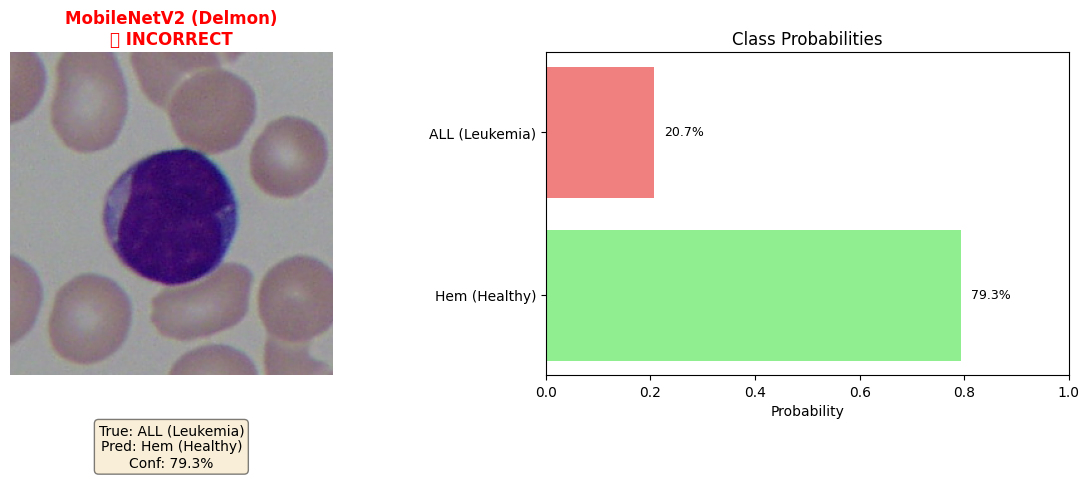


Testing: DenseNet-121 (Durdans)
Architecture: densenet121
Model Path: /content/drive/MyDrive/College/models/Durdans.pt
Building densenet121 architecture...
Loading weights from Durdans.pt...
   ✓ Loaded from checkpoint (round 5)
✅ Model loaded successfully
Processing image: allidb_Im004_1.tif...

📊 Results:
   True Label:  ALL (Leukemia)
   Predicted:   Hem (Healthy)
   Confidence:  99.00%
   Logits:      [ 1.1646317 -3.4318264]
   Probs:       Healthy=99.00%, Leukemia=1.00%
   Status:      ❌ INCORRECT


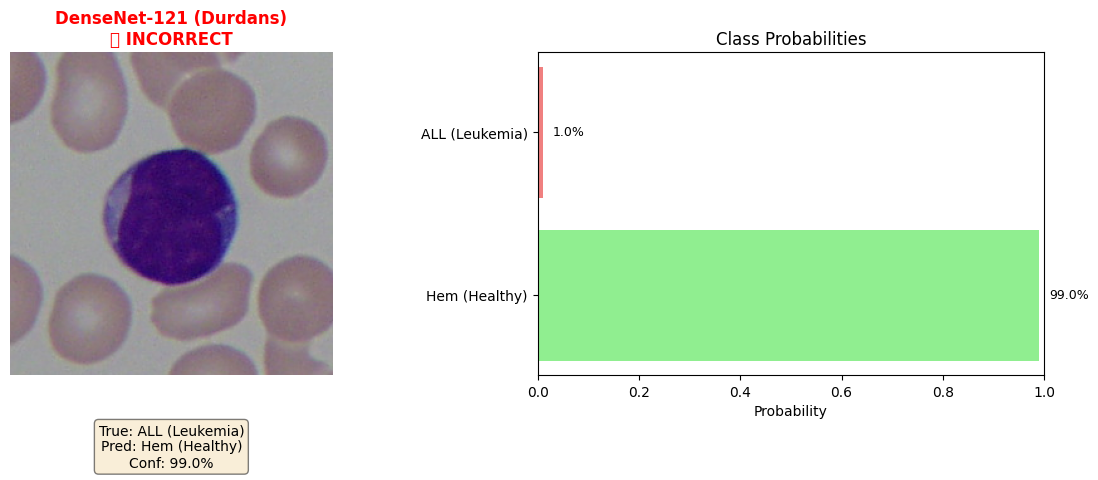


SUMMARY COMPARISON
❌ ResNet-18 (Asiri)              → Hem (Healthy)   (99.3%)
❌ MobileNetV2 (Delmon)           → Hem (Healthy)   (79.3%)
❌ DenseNet-121 (Durdans)         → Hem (Healthy)   (99.0%)

🤝 Consensus: All models agree on 'Hem (Healthy)'


In [ ]:
"""
Inference Script for FLEX-Med Models
Tests Hospital_A.pt (ResNet-18), Hospital_B.pt (MobileNetV2), Hospital_C.pt (DenseNet-121)
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, models
from PIL import Image
import os
import json

# ==========================================
# 1. CONFIGURATION
# ==========================================

# Paths to your trained models
MODELS = {
    "Hospital_A": {
        "path": "/content/drive/MyDrive/College/models/Asiri.pt",
        "architecture": "resnet18",
        "name": "ResNet-18 (Asiri)"
    },
    "Hospital_B": {
        "path": "/content/drive/MyDrive/College/models/Delmon.pt",
        "architecture": "mobilenet_v2",
        "name": "MobileNetV2 (Delmon)"
    },
    "Hospital_C": {
        "path": "/content/drive/MyDrive/College/models/Durdans.pt",
        "architecture": "densenet121",
        "name": "DenseNet-121 (Durdans)"
    }
}

# Test image path
IMAGE_PATH = "/content/drive/MyDrive/College/FLEX-Med/datasets/public_anchor/all/allidb_Im004_1.tif" # Leukemia
# IMAGE_PATH = "/content/drive/MyDrive/College/FLEX-Med/datasets/all_idb2_raw/hem/allidb_Im131_0.tif" # Healthy

# CORRECT CLASS LABELS (matching task.py)
CLASSES = ['Hem (Healthy)', 'ALL (Leukemia)']  # 0: Healthy, 1: Leukemia
NUM_CLASSES = 2
IMG_SIZE = 128  # Must match training size

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. MODEL BUILDERS (Match task.py exactly)
# ==========================================

def get_resnet18():
    """Build ResNet-18 for binary classification"""
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model

def get_mobilenet_v2():
    """Build MobileNetV2 for binary classification"""
    model = models.mobilenet_v2(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    return model

def get_densenet121():
    """Build DenseNet-121 for binary classification"""
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    return model

def build_model(architecture):
    """
    Build model based on architecture name.
    Must match exactly how they were created in task.py
    """
    arch = architecture.lower()

    if arch == "resnet18":
        return get_resnet18()
    elif arch == "mobilenet_v2":
        return get_mobilenet_v2()
    elif arch == "densenet121":
        return get_densenet121()
    else:
        raise ValueError(f"Unknown architecture: {architecture}")

def load_model_weights(model, model_path, device):
    """
    Safely load model weights, handling both formats:
    - Direct state_dict
    - Checkpoint with metadata (model_type, num_classes, state_dict, etc.)
    """
    checkpoint = torch.load(model_path, map_location=device)

    # Check if it's nested with 'state_dict' key
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        # Load from nested checkpoint
        model.load_state_dict(checkpoint['state_dict'])
        print(f"   ✓ Loaded from checkpoint (round {checkpoint.get('round', 'unknown')})")
    else:
        # Load directly
        model.load_state_dict(checkpoint)
        print(f"   ✓ Loaded direct state_dict")

    return model

# ==========================================
# 3. IMAGE PREPROCESSING (Match training)
# ==========================================

def get_transform():
    """
    Same transform used during training/inference in task.py
    CRITICAL: Must use same normalization and size as training!
    """
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
    ])

def load_and_preprocess_image(image_path):
    """Load image and apply preprocessing"""
    img = Image.open(image_path).convert('RGB')
    transform = get_transform()
    input_tensor = transform(img).unsqueeze(0)
    return input_tensor, img

# ==========================================
# 4. INFERENCE FUNCTION
# ==========================================

def predict_with_model(model_info, image_path, display=True):
    """
    Run inference with a single model

    Args:
        model_info: Dict with 'path', 'architecture', 'name'
        image_path: Path to test image
        display: Whether to show visualization

    Returns:
        Dict with prediction results
    """
    model_path = model_info['path']
    architecture = model_info['architecture']
    model_name = model_info['name']

    print(f"\n{'='*60}")
    print(f"Testing: {model_name}")
    print(f"Architecture: {architecture}")
    print(f"Model Path: {model_path}")
    print(f"{'='*60}")

    # Check if model exists
    if not os.path.exists(model_path):
        print(f"❌ Error: Model not found at {model_path}")
        return None

    # Check if image exists
    if not os.path.exists(image_path):
        print(f"❌ Error: Image not found at {image_path}")
        return None

    try:
        # 1. Build model architecture
        print(f"Building {architecture} architecture...")
        model = build_model(architecture)
        model.to(DEVICE)

        # 2. Load trained weights - FIXED! Now uses helper function
        print(f"Loading weights from {os.path.basename(model_path)}...")
        model = load_model_weights(model, model_path, DEVICE)
        model.eval()
        print("✅ Model loaded successfully")

        # 3. Load and preprocess image
        print(f"Processing image: {os.path.basename(image_path)}...")
        input_tensor, original_img = load_and_preprocess_image(image_path)
        input_tensor = input_tensor.to(DEVICE)

        # 4. Run inference
        with torch.no_grad():
            outputs = model(input_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            pred_idx = outputs.argmax(dim=1).item()
            confidence = probs[0][pred_idx].item()

        pred_label = CLASSES[pred_idx]

        # 5. Infer ground truth from folder name
        parent_folder = os.path.basename(os.path.dirname(image_path)).lower()
        true_label = "Unknown"
        is_correct = None

        if "hem" in parent_folder:
            true_label = CLASSES[0]  # Healthy
            is_correct = (pred_idx == 0)
        elif "all" in parent_folder:
            true_label = CLASSES[1]  # Leukemia
            is_correct = (pred_idx == 1)

        # 6. Display results
        print(f"\n📊 Results:")
        print(f"   True Label:  {true_label}")
        print(f"   Predicted:   {pred_label}")
        print(f"   Confidence:  {confidence:.2%}")
        print(f"   Logits:      {outputs[0].cpu().numpy()}")
        print(f"   Probs:       Healthy={probs[0][0].item():.2%}, Leukemia={probs[0][1].item():.2%}")

        if is_correct is not None:
            status = "✅ CORRECT" if is_correct else "❌ INCORRECT"
            print(f"   Status:      {status}")

        # 7. Visualize (if requested)
        if display:
            visualize_prediction(
                original_img,
                model_name,
                true_label,
                pred_label,
                confidence,
                probs[0].cpu().numpy(),
                is_correct
            )

        return {
            "model": model_name,
            "architecture": architecture,
            "true_label": true_label,
            "predicted_label": pred_label,
            "prediction_idx": pred_idx,
            "confidence": confidence,
            "probabilities": probs[0].cpu().numpy(),
            "logits": outputs[0].cpu().numpy(),
            "correct": is_correct
        }

    except Exception as e:
        print(f"❌ Error during inference: {e}")
        import traceback
        traceback.print_exc()
        return None

# ==========================================
# 5. VISUALIZATION
# ==========================================

def visualize_prediction(img, model_name, true_label, pred_label, confidence, probs, is_correct):
    """Create visualization of prediction"""

    # Determine color based on correctness
    if is_correct is None:
        color = 'blue'
        status = ''
    elif is_correct:
        color = 'green'
        status = '✅ CORRECT'
    else:
        color = 'red'
        status = '❌ INCORRECT'

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: Image
    ax1.imshow(img)
    ax1.set_title(f"{model_name}\n{status}",
                  color=color, fontweight='bold', fontsize=12)
    ax1.axis('off')

    # Add text info below image
    info_text = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1%}"
    ax1.text(0.5, -0.15, info_text,
             transform=ax1.transAxes,
             ha='center', va='top',
             fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Right: Probability bar chart
    ax2.barh(CLASSES, probs, color=['lightgreen', 'lightcoral'])
    ax2.set_xlabel('Probability', fontsize=10)
    ax2.set_title('Class Probabilities', fontsize=12)
    ax2.set_xlim([0, 1])

    # Add percentage labels on bars
    for i, (cls, prob) in enumerate(zip(CLASSES, probs)):
        ax2.text(prob + 0.02, i, f'{prob:.1%}',
                va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

# ==========================================
# 6. BATCH TESTING
# ==========================================

def test_all_models(image_path):
    """
    Test all three models on the same image and compare results
    """
    print("\n" + "="*70)
    print("FLEX-Med Model Testing Suite")
    print(f"Testing Image: {os.path.basename(image_path)}")
    print("="*70)

    results = []

    for model_key, model_info in MODELS.items():
        result = predict_with_model(model_info, image_path, display=True)
        if result:
            results.append(result)

    # Summary comparison
    if results:
        print("\n" + "="*70)
        print("SUMMARY COMPARISON")
        print("="*70)

        for r in results:
            status = "✅" if r['correct'] else "❌" if r['correct'] is not None else "❓"
            print(f"{status} {r['model']:30} → {r['predicted_label']:15} ({r['confidence']:.1%})")

        # Consensus check
        predictions = [r['prediction_idx'] for r in results]
        if len(set(predictions)) == 1:
            print(f"\n🤝 Consensus: All models agree on '{results[0]['predicted_label']}'")
        else:
            print(f"\n⚠️  Disagreement: Models have different predictions")
            healthy_votes = sum(1 for p in predictions if p == 0)
            leukemia_votes = sum(1 for p in predictions if p == 1)
            print(f"   Healthy: {healthy_votes} votes")
            print(f"   Leukemia: {leukemia_votes} votes")

        print("="*70)

    return results

# ==========================================
# 7. CONVENIENCE FUNCTIONS
# ==========================================

def test_single_model(model_key, image_path):
    """Test a specific model"""
    if model_key not in MODELS:
        print(f"❌ Unknown model: {model_key}")
        print(f"Available models: {list(MODELS.keys())}")
        return None

    return predict_with_model(MODELS[model_key], image_path, display=True)

def test_on_directory(model_key, directory_path, max_images=5):
    """Test a model on multiple images from a directory"""
    if model_key not in MODELS:
        print(f"❌ Unknown model: {model_key}")
        return

    # Get all image files
    image_extensions = ['.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp']
    image_files = []

    for file in os.listdir(directory_path):
        if any(file.lower().endswith(ext) for ext in image_extensions):
            image_files.append(os.path.join(directory_path, file))

    image_files = image_files[:max_images]

    print(f"\nTesting {model_key} on {len(image_files)} images from {directory_path}")

    results = []
    for img_path in image_files:
        result = predict_with_model(MODELS[model_key], img_path, display=False)
        if result:
            results.append(result)

    # Summary
    if results:
        correct = sum(1 for r in results if r['correct'])
        total = len([r for r in results if r['correct'] is not None])
        accuracy = correct / total if total > 0 else 0

        print(f"\n📊 Batch Results for {model_key}:")
        print(f"   Tested: {len(results)} images")
        print(f"   Correct: {correct}/{total}")
        print(f"   Accuracy: {accuracy:.1%}")

# ==========================================
# 8. MAIN EXECUTION
# ==========================================

if __name__ == "__main__":
    # Option 1: Test all three models on one image
    results = test_all_models(IMAGE_PATH)

    # Option 2: Test a specific model
    # test_single_model("Hospital_A", IMAGE_PATH)

    # Option 3: Test on multiple images
    # test_on_directory("Hospital_A", "/content/drive/MyDrive/College/FLEX-Med/datasets/public_anchor/hem", max_images=10)

In [ ]:
"""
FLEX-Med Performance Visualization
Run this cell AFTER FL completes to visualize Pre-FL vs Post-FL metrics

This cell reads from data.json and generates:
1. Accuracy Improvement Bar Chart
2. Multi-Metric Comparison (Radar Charts)
3. Improvement Heatmap
4. Confusion Matrices (Before/After)
5. Class-Specific Performance
6. Complete Summary Dashboard
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ==========================================
# CONFIGURATION
# ==========================================

DATA_JSON_PATH = "/content/drive/MyDrive/College/FLEX-Med/flex-med/flex_med/data.json"

# ==========================================
# LOAD DATA
# ==========================================

def load_metrics_from_json():
    """Load all client metrics from data.json"""
    with open(DATA_JSON_PATH, 'r') as f:
        clients = json.load(f)

    metrics_data = []
    for client in clients:
        metrics = json.loads(client['metrics'])
        metrics_data.append({
            'id': client['id'],
            'name': client['client_name'],
            'model_type': client['model_type'],
            'has_data': client['has_local_data'],
            'metrics': metrics
        })

    return metrics_data

# ==========================================
# VISUALIZATION 1: ACCURACY IMPROVEMENT
# ==========================================

def plot_accuracy_improvement(data):
    """Bar chart showing pre-FL vs post-FL accuracy"""
    fig, ax = plt.subplots(figsize=(12, 6))

    clients = []
    pre_acc = []
    post_acc = []
    colors = []

    for client in data:
        if 'pre_fl' in client['metrics'] and 'post_fl' in client['metrics']:
            clients.append(client['name'])
            pre_acc.append(client['metrics']['pre_fl']['accuracy'] * 100)
            post_acc.append(client['metrics']['post_fl']['accuracy'] * 100)

            # Color based on improvement
            if post_acc[-1] > pre_acc[-1]:
                colors.append('#2ecc71')  # Green
            else:
                colors.append('#e74c3c')  # Red

    x = np.arange(len(clients))
    width = 0.35

    bars1 = ax.bar(x - width/2, pre_acc, width, label='Pre-FL', alpha=0.8, color='#3498db')
    bars2 = ax.bar(x + width/2, post_acc, width, label='Post-FL', alpha=0.8, color=colors)

    # Add improvement labels
    for i in range(len(clients)):
        improvement = post_acc[i] - pre_acc[i]
        y_pos = max(pre_acc[i], post_acc[i]) + 3
        arrow = '↑' if improvement > 0 else '↓'
        color = '#2ecc71' if improvement > 0 else '#e74c3c'

        ax.text(x[i], y_pos, f'{arrow} {abs(improvement):.1f}%',
               ha='center', fontsize=11, fontweight='bold', color=color)

    ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
    ax.set_title('Model Accuracy: Pre-FL vs Post-FL', fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(clients, rotation=0, ha='center', fontsize=11)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 110)

    # Add baseline at 50%
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax.text(len(clients)-0.5, 52, 'Random (50%)', fontsize=9, alpha=0.5)

    plt.tight_layout()
    plt.show()

# ==========================================
# VISUALIZATION 2: MULTI-METRIC RADAR
# ==========================================

def plot_multi_metric_comparison(data):
    """Radar charts comparing multiple metrics"""
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

    n_clients = len([c for c in data if 'pre_fl' in c['metrics'] and 'post_fl' in c['metrics']])
    fig, axes = plt.subplots(1, n_clients, figsize=(5*n_clients, 5),
                            subplot_kw=dict(projection='polar'))

    if n_clients == 1:
        axes = [axes]

    idx = 0
    for client in data:
        if 'pre_fl' in client['metrics'] and 'post_fl' in client['metrics']:
            ax = axes[idx]

            pre_values = [client['metrics']['pre_fl'][m] for m in metrics_to_plot]
            post_values = [client['metrics']['post_fl'][m] for m in metrics_to_plot]

            # Close the plot
            pre_values += pre_values[:1]
            post_values += post_values[:1]

            angles = np.linspace(0, 2 * np.pi, len(metric_labels), endpoint=False).tolist()
            angles += angles[:1]

            # Plot
            ax.plot(angles, pre_values, 'o-', linewidth=2, label='Pre-FL',
                   color='#3498db', alpha=0.7)
            ax.fill(angles, pre_values, alpha=0.15, color='#3498db')

            ax.plot(angles, post_values, 'o-', linewidth=2, label='Post-FL',
                   color='#2ecc71', alpha=0.7)
            ax.fill(angles, post_values, alpha=0.15, color='#2ecc71')

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(metric_labels, size=10)
            ax.set_ylim(0, 1)
            ax.set_title(f'{client["name"]}\n({client["model_type"]})',
                        size=12, fontweight='bold', pad=20)
            ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
            ax.grid(True, alpha=0.3)

            idx += 1

    plt.suptitle('Multi-Metric Performance Comparison',
                fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# ==========================================
# VISUALIZATION 3: IMPROVEMENT HEATMAP
# ==========================================

def plot_improvement_heatmap(data):
    """Heatmap showing improvement across metrics"""
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

    clients = []
    improvement_matrix = []

    for client in data:
        if 'improvement' in client['metrics']:
            clients.append(client['name'])
            improvements = [client['metrics']['improvement'][m] * 100
                          for m in metrics_to_plot]
            improvement_matrix.append(improvements)

    if not improvement_matrix:
        print("⚠️ No improvement data available yet. Run FL first!")
        return

    improvement_matrix = np.array(improvement_matrix)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Use diverging colormap
    im = ax.imshow(improvement_matrix, cmap='RdYlGn', aspect='auto',
                  vmin=-10, vmax=20, interpolation='nearest')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Improvement (%)', rotation=270, labelpad=25, fontsize=12, fontweight='bold')

    # Set ticks
    ax.set_xticks(np.arange(len(metric_labels)))
    ax.set_yticks(np.arange(len(clients)))
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_yticklabels(clients, fontsize=11)

    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add text annotations
    for i in range(len(clients)):
        for j in range(len(metric_labels)):
            value = improvement_matrix[i, j]
            text_color = 'white' if abs(value) > 10 else 'black'
            ax.text(j, i, f'{value:.1f}%',
                   ha="center", va="center", color=text_color,
                   fontsize=10, fontweight='bold')

    ax.set_title('Performance Improvement After Federated Learning',
                fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

# ==========================================
# VISUALIZATION 4: CONFUSION MATRICES
# ==========================================

def plot_confusion_matrices(data):
    """Side-by-side confusion matrices"""
    n_clients = len([c for c in data if 'pre_fl' in c['metrics'] and 'post_fl' in c['metrics']])

    if n_clients == 0:
        print("⚠️ No evaluation data available yet!")
        return

    fig, axes = plt.subplots(n_clients, 2, figsize=(10, 4*n_clients))

    if n_clients == 1:
        axes = axes.reshape(1, -1)

    row = 0
    for client in data:
        if 'pre_fl' in client['metrics'] and 'post_fl' in client['metrics']:
            # Pre-FL
            cm_pre = np.array(client['metrics']['pre_fl']['confusion_matrix'])
            sns.heatmap(cm_pre, annot=True, fmt='d', cmap='Blues',
                       xticklabels=['Healthy', 'Leukemia'],
                       yticklabels=['Healthy', 'Leukemia'],
                       ax=axes[row, 0], cbar=False, annot_kws={"size": 14})
            axes[row, 0].set_title(f"{client['name']} - Pre-FL\nAcc: {client['metrics']['pre_fl']['accuracy']:.1%}",
                                  fontsize=12, fontweight='bold')
            axes[row, 0].set_ylabel('True Label', fontsize=11)
            axes[row, 0].set_xlabel('Predicted Label', fontsize=11)

            # Post-FL
            cm_post = np.array(client['metrics']['post_fl']['confusion_matrix'])
            sns.heatmap(cm_post, annot=True, fmt='d', cmap='Greens',
                       xticklabels=['Healthy', 'Leukemia'],
                       yticklabels=['Healthy', 'Leukemia'],
                       ax=axes[row, 1], cbar=False, annot_kws={"size": 14})
            axes[row, 1].set_title(f"{client['name']} - Post-FL\nAcc: {client['metrics']['post_fl']['accuracy']:.1%}",
                                  fontsize=12, fontweight='bold')
            axes[row, 1].set_ylabel('True Label', fontsize=11)
            axes[row, 1].set_xlabel('Predicted Label', fontsize=11)

            row += 1

    plt.suptitle('Confusion Matrices: Before and After FL',
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# ==========================================
# VISUALIZATION 5: CLASS-SPECIFIC ACCURACY
# ==========================================

def plot_class_specific_accuracy(data):
    """Bar chart for Healthy vs Leukemia accuracy"""
    fig, ax = plt.subplots(figsize=(12, 6))

    clients = []
    healthy_pre = []
    healthy_post = []
    leukemia_pre = []
    leukemia_post = []

    for client in data:
        if 'pre_fl' in client['metrics'] and 'post_fl' in client['metrics']:
            clients.append(client['name'])
            healthy_pre.append(client['metrics']['pre_fl']['healthy_accuracy'] * 100)
            healthy_post.append(client['metrics']['post_fl']['healthy_accuracy'] * 100)
            leukemia_pre.append(client['metrics']['pre_fl']['leukemia_accuracy'] * 100)
            leukemia_post.append(client['metrics']['post_fl']['leukemia_accuracy'] * 100)

    x = np.arange(len(clients))
    width = 0.2

    ax.bar(x - 1.5*width, healthy_pre, width, label='Healthy (Pre-FL)',
          alpha=0.8, color='#85c1e2')
    ax.bar(x - 0.5*width, healthy_post, width, label='Healthy (Post-FL)',
          alpha=0.8, color='#3498db')
    ax.bar(x + 0.5*width, leukemia_pre, width, label='Leukemia (Pre-FL)',
          alpha=0.8, color='#f1948a')
    ax.bar(x + 1.5*width, leukemia_post, width, label='Leukemia (Post-FL)',
          alpha=0.8, color='#e74c3c')

    ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
    ax.set_title('Class-Specific Accuracy: Healthy vs Leukemia',
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(clients, rotation=0, ha='center', fontsize=11)
    ax.legend(fontsize=10, loc='lower right', ncol=2)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 110)

    plt.tight_layout()
    plt.show()

# ==========================================
# VISUALIZATION 6: SUMMARY DASHBOARD
# ==========================================

def create_summary_dashboard(data):
    """Comprehensive dashboard with all metrics"""
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Accuracy Comparison (top left, wide)
    ax1 = fig.add_subplot(gs[0, :2])
    clients = []
    pre_acc = []
    post_acc = []

    for client in data:
        if 'pre_fl' in client['metrics'] and 'post_fl' in client['metrics']:
            clients.append(client['name'])
            pre_acc.append(client['metrics']['pre_fl']['accuracy'] * 100)
            post_acc.append(client['metrics']['post_fl']['accuracy'] * 100)

    x = np.arange(len(clients))
    width = 0.35
    ax1.bar(x - width/2, pre_acc, width, label='Pre-FL', alpha=0.8, color='#3498db')
    ax1.bar(x + width/2, post_acc, width, label='Post-FL', alpha=0.8, color='#2ecc71')
    ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
    ax1.set_title('Accuracy Improvement', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(clients, rotation=45, ha='right')
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim(0, 100)

    # 2. Improvement Summary (top right)
    ax2 = fig.add_subplot(gs[0, 2])
    improvements = []
    for client in data:
        if 'improvement' in client['metrics']:
            improvements.append(client['metrics']['improvement']['accuracy'] * 100)

    colors_bar = ['#2ecc71' if x > 0 else '#e74c3c' for x in improvements]
    ax2.barh(clients, improvements, color=colors_bar, alpha=0.8)
    ax2.set_xlabel('Improvement (%)', fontsize=10, fontweight='bold')
    ax2.set_title('Accuracy Change', fontsize=13, fontweight='bold')
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax2.grid(axis='x', alpha=0.3)

    # 3. Heatmap (middle row, full width)
    ax3 = fig.add_subplot(gs[1, :])
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

    improvement_matrix = []
    for client in data:
        if 'improvement' in client['metrics']:
            improvements = [client['metrics']['improvement'][m] * 100
                          for m in metrics_to_plot]
            improvement_matrix.append(improvements)

    if improvement_matrix:
        improvement_matrix = np.array(improvement_matrix)
        im = ax3.imshow(improvement_matrix, cmap='RdYlGn', aspect='auto',
                       vmin=-10, vmax=20, interpolation='nearest')
        ax3.set_xticks(np.arange(len(metric_labels)))
        ax3.set_yticks(np.arange(len(clients)))
        ax3.set_xticklabels(metric_labels, fontsize=10)
        ax3.set_yticklabels(clients, fontsize=10)
        ax3.set_title('Multi-Metric Improvement (%)', fontsize=13, fontweight='bold')

        for i in range(len(clients)):
            for j in range(len(metric_labels)):
                value = improvement_matrix[i, j]
                text_color = 'white' if abs(value) > 10 else 'black'
                ax3.text(j, i, f'{value:.1f}',
                        ha="center", va="center", fontsize=9,
                        color=text_color, fontweight='bold')

    # 4. Class-specific metrics (bottom row)
    for idx, client in enumerate(data[:3]):  # First 3 clients
        if 'pre_fl' in client['metrics'] and 'post_fl' in client['metrics']:
            ax = fig.add_subplot(gs[2, idx])

            categories = ['Healthy\nPre', 'Healthy\nPost', 'Leukemia\nPre', 'Leukemia\nPost']
            values = [
                client['metrics']['pre_fl']['healthy_accuracy'] * 100,
                client['metrics']['post_fl']['healthy_accuracy'] * 100,
                client['metrics']['pre_fl']['leukemia_accuracy'] * 100,
                client['metrics']['post_fl']['leukemia_accuracy'] * 100,
            ]
            colors_class = ['#85c1e2', '#3498db', '#f1948a', '#e74c3c']

            ax.bar(range(4), values, color=colors_class, alpha=0.8)
            ax.set_xticks(range(4))
            ax.set_xticklabels(categories, fontsize=8)
            ax.set_ylabel('Accuracy (%)', fontsize=9)
            ax.set_title(f'{client["name"]}', fontweight='bold', fontsize=10)
            ax.set_ylim(0, 105)
            ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Federated Learning Performance Dashboard',
                fontsize=18, fontweight='bold', y=0.98)

    plt.tight_layout()
    plt.show()

# ==========================================
# SUMMARY TABLE
# ==========================================

def print_summary_table(data):
    """Print formatted summary table"""
    print("\n" + "="*90)
    print("FEDERATED LEARNING PERFORMANCE SUMMARY")
    print("="*90)

    print(f"\n{'Client':<20} {'Model':<15} {'Pre-FL':<12} {'Post-FL':<12} {'Improvement':<15}")
    print("-"*90)

    for client in data:
        if 'pre_fl' in client['metrics'] and 'post_fl' in client['metrics']:
            name = client['name']
            model = client['model_type']
            pre = client['metrics']['pre_fl']['accuracy']
            post = client['metrics']['post_fl']['accuracy']
            imp = client['metrics']['improvement']['accuracy']

            imp_str = f"{imp:+.2%}"
            if imp > 0:
                imp_str = "🟢 " + imp_str
            elif imp < 0:
                imp_str = "🔴 " + imp_str

            print(f"{name:<20} {model:<15} {pre:<11.2%} {post:<11.2%} {imp_str:<15}")

    print("="*90)

    # Overall statistics
    improvements = [c['metrics']['improvement']['accuracy']
                   for c in data if 'improvement' in c['metrics']]

    if improvements:
        print(f"\n📊 Overall Statistics:")
        print(f"   Average Improvement: {np.mean(improvements):+.2%}")
        print(f"   Best Improvement:    {max(improvements):+.2%}")
        print(f"   Worst Improvement:   {min(improvements):+.2%}")
        print(f"   Clients Improved:    {sum(1 for x in improvements if x > 0)}/{len(improvements)}")
        print(f"   Success Rate:        {sum(1 for x in improvements if x > 0)/len(improvements):.1%}")

    print("\n" + "="*90 + "\n")

# ==========================================
# MAIN EXECUTION
# ==========================================

def visualize_all():
    """Run all visualizations"""

    print("\n" + "="*70)
    print("FLEX-Med Performance Visualization")
    print("="*70)

    # Load data
    print("\n📂 Loading metrics from data.json...")
    try:
        data = load_metrics_from_json()
        print(f"✅ Loaded metrics for {len(data)} clients")
    except FileNotFoundError:
        print(f"❌ Error: data.json not found at {DATA_JSON_PATH}")
        return
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return

    # Check if we have evaluation data
    has_pre = any('pre_fl' in c['metrics'] for c in data)
    has_post = any('post_fl' in c['metrics'] for c in data)

    if not has_pre:
        print("\n⚠️ No Pre-FL evaluation data found.")
        print("   Run FL training first to capture baseline metrics.")
        return

    if not has_post:
        print("\n⚠️ Pre-FL data found, but no Post-FL data yet.")
        print("   FL simulation is either running or hasn't started.")
        print("   Post-FL metrics will be available after FL completes.")
        return

    print("\n✅ Both Pre-FL and Post-FL data available!")
    print("\nGenerating visualizations...\n")

    # Print summary table
    print_summary_table(data)

    # Generate all plots
    print("📊 1. Accuracy Improvement Bar Chart")
    plot_accuracy_improvement(data)

    print("\n📊 2. Multi-Metric Radar Charts")
    plot_multi_metric_comparison(data)

    print("\n📊 3. Improvement Heatmap")
    plot_improvement_heatmap(data)

    print("\n📊 4. Confusion Matrices")
    plot_confusion_matrices(data)

    print("\n📊 5. Class-Specific Accuracy")
    plot_class_specific_accuracy(data)

    print("\n📊 6. Complete Summary Dashboard")
    create_summary_dashboard(data)

    print("\n" + "="*70)
    print("✅ All visualizations generated!")
    print("="*70 + "\n")

# Run all visualizations
visualize_all()

# ==========================================
# INDIVIDUAL VISUALIZATION FUNCTIONS
# ==========================================

# You can also run individual visualizations:
#
# data = load_metrics_from_json()
# plot_accuracy_improvement(data)
# plot_multi_metric_comparison(data)
# plot_improvement_heatmap(data)
# plot_confusion_matrices(data)
# plot_class_specific_accuracy(data)
# create_summary_dashboard(data)


FLEX-Med Performance Visualization

📂 Loading metrics from data.json...
✅ Loaded metrics for 3 clients

⚠️ No Pre-FL evaluation data found.
   Run FL training first to capture baseline metrics.


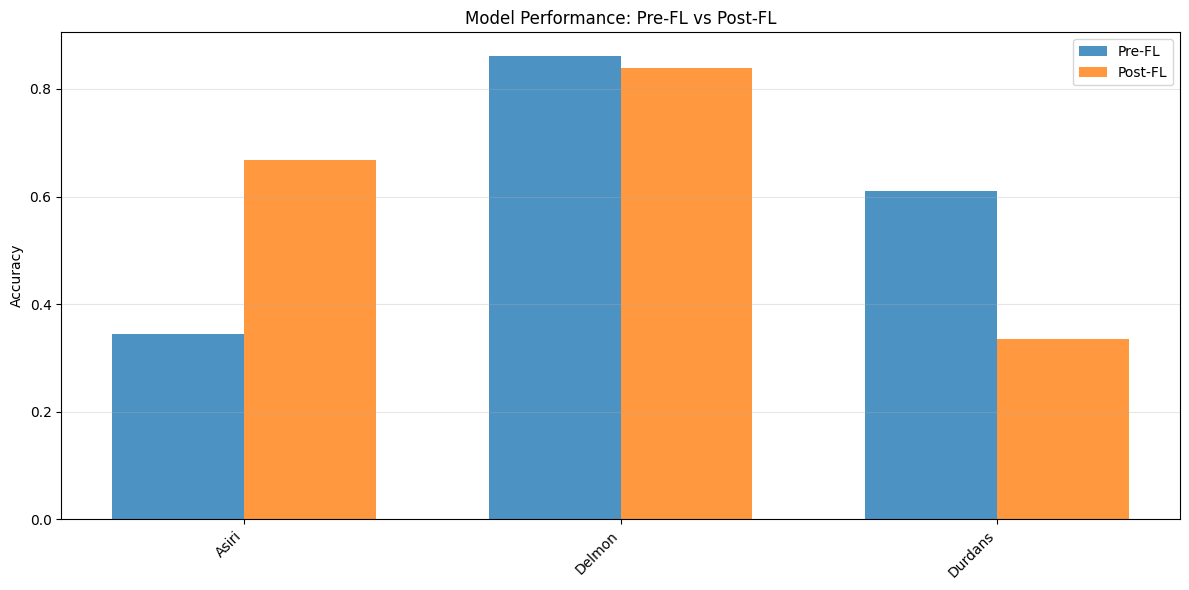

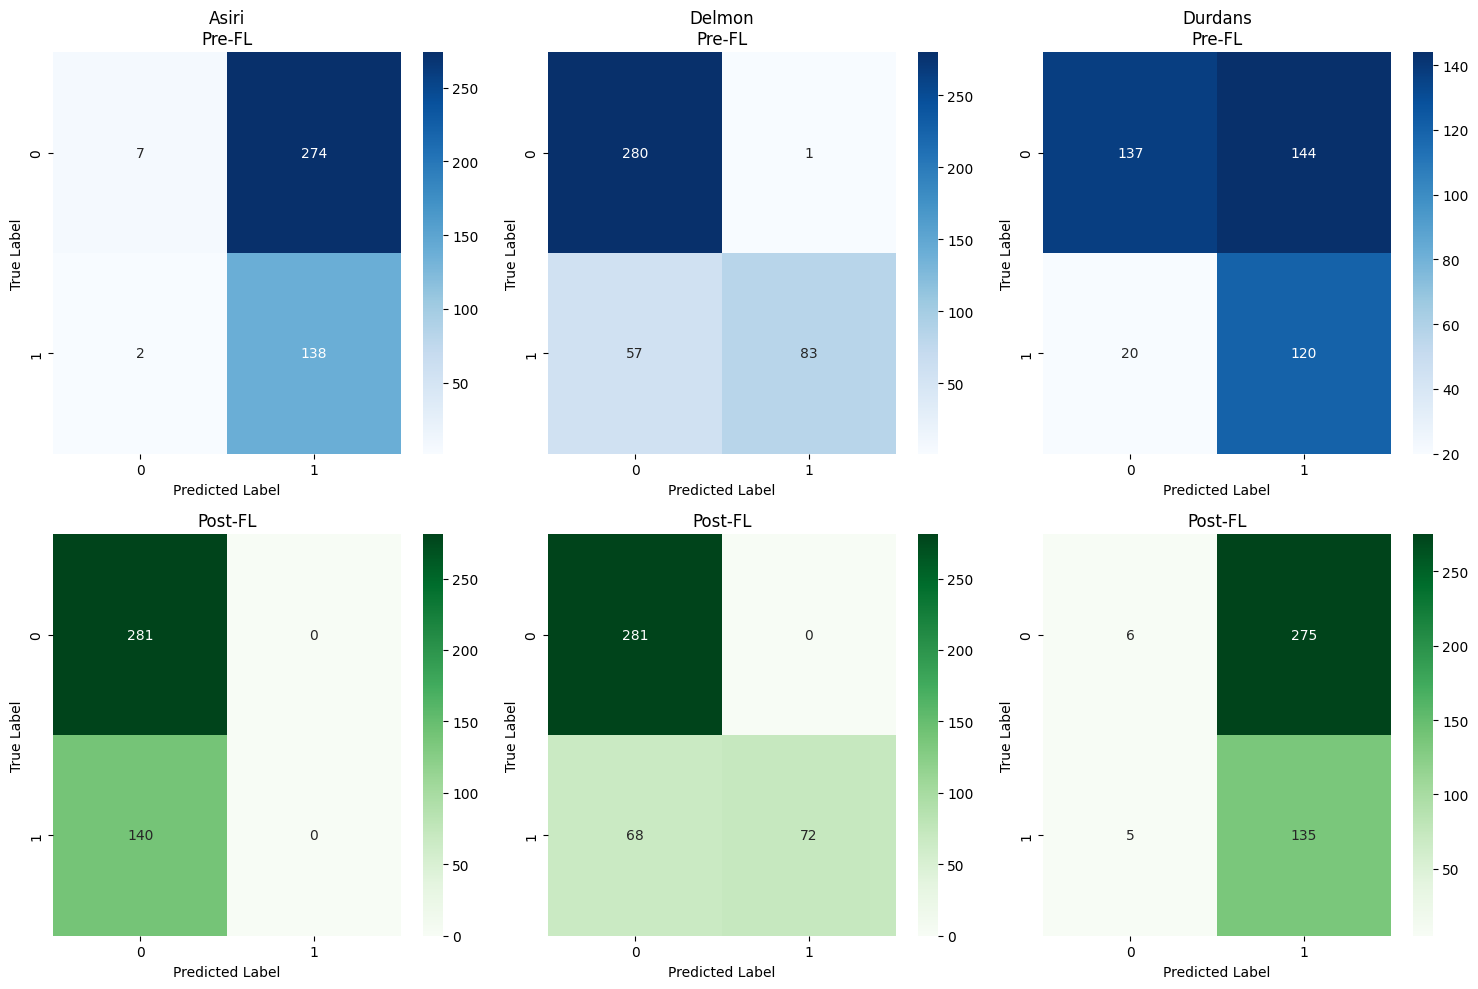

In [ ]:
# evaluation_visualizer.py (NEW FILE)

import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

DATA_JSON_PATH = "/content/drive/MyDrive/College/FLEX-Med/flex-med/flex_med/data.json"

def load_results():
    """Load evaluation results from data.json"""
    with open(DATA_JSON_PATH, 'r') as f:
        clients = json.load(f)
    return clients

def plot_accuracy_comparison(clients):
    """Bar chart: Pre-FL vs Post-FL accuracy"""
    names = [c['client_name'] for c in clients]
    pre_acc = [c['metrics']['pre_fl']['accuracy'] for c in clients]
    post_acc = [c['metrics']['post_fl']['accuracy'] for c in clients]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width/2, pre_acc, width, label='Pre-FL', alpha=0.8)
    ax.bar(x + width/2, post_acc, width, label='Post-FL', alpha=0.8)

    ax.set_ylabel('Accuracy')
    ax.set_title('Model Performance: Pre-FL vs Post-FL')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('accuracy_comparison.png', dpi=300)
    plt.show()

def plot_confusion_matrices(clients):
    """Confusion matrices for each client"""
    n_clients = len(clients)
    fig, axes = plt.subplots(2, n_clients, figsize=(5*n_clients, 10))

    for i, client in enumerate(clients):
        # Pre-FL
        cm_pre = np.array(client['metrics']['pre_fl']['confusion_matrix'])
        sns.heatmap(cm_pre, annot=True, fmt='d', ax=axes[0, i], cmap='Blues')
        axes[0, i].set_title(f"{client['client_name']}\nPre-FL")
        axes[0, i].set_ylabel('True Label')
        axes[0, i].set_xlabel('Predicted Label')

        # Post-FL
        cm_post = np.array(client['metrics']['post_fl']['confusion_matrix'])
        sns.heatmap(cm_post, annot=True, fmt='d', ax=axes[1, i], cmap='Greens')
        axes[1, i].set_title(f"Post-FL")
        axes[1, i].set_ylabel('True Label')
        axes[1, i].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300)
    plt.show()

def plot_metrics_radar(clients):
    """Radar chart for comprehensive metrics"""
    # Implementation here...
    pass

if __name__ == "__main__":
    clients = load_results()

    plot_accuracy_comparison(clients)
    plot_confusion_matrices(clients)
    # Add more visualizations...

In [ ]:
import os

# Define the paths
# base_path = '/content/drive/MyDrive/College/FLEX-Med/datasets/all_idb2_raw'
# base_path = '/content/drive/MyDrive/College/FLEX-Med/datasets/cnmc_balanced'
# base_path = '/content/drive/MyDrive/College/FLEX-Med/datasets/public_anchor'
base_path = '/content/drive/MyDrive/College/FLEX-Med/datasets/public_test'
all_folder = os.path.join(base_path, 'all')
hem_folder = os.path.join(base_path, 'hem')

# Check if the paths exist before counting to avoid errors
if os.path.exists(all_folder) and os.path.exists(hem_folder):
    # Count the files in each directory
    # Note: This counts all files. If you have hidden files (like .ipynb_checkpoints),
    # you might want to filter by extension (e.g., .jpg, .png).
    count_all = len(os.listdir(all_folder))
    count_hem = len(os.listdir(hem_folder))

    print(f"Number of images in 'all' folder: {count_all}")
    print(f"Number of images in 'hem' folder: {count_hem}")
    print(f"Total images: {count_all + count_hem}")

else:
    print("Error: One or both folder paths do not exist.")
    print(f"Checked: {all_folder}")
    print(f"Checked: {hem_folder}")
    print("Please ensure your Google Drive is mounted.")

Number of images in 'all' folder: 1128
Number of images in 'hem' folder: 563
Total images: 1691
